# Unit 4: BrainFlow 信号处理 API

## 学习目标
- 掌握 DataFilter 的各种滤波操作
- 理解去趋势（Detrending）的意义和应用
- 学习小波去噪与滚动平滑
- 熟练使用 FilterTypes、DetrendOperations、AggOperations 等枚举
- 对比不同滤波方法的效果

In [ ]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
# 负责采集数据
from brainflow.board_shim import (
    BoardShim,                   # 板卡接口
    BrainFlowInputParams,        # 输入参数
    BrainFlowPresets,            # 预设
    BoardIds                     # 板卡ID
)
# 负责数据处理
from brainflow.data_filter import (
    DataFilter,                  # 数据滤波器
    FilterTypes,                 # 滤波器类型
    WaveletTypes,                # 小波类型
    NoiseTypes,                  # 工频噪声类型
    AggOperations,               # 聚合操作
    DetrendOperations,           # 去趋势操作
    WindowOperations             # 窗口操作
)

# 设置中文字体
if os.name == 'nt':
    plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
elif os.name == 'posix': # macos 或 linux
    plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
print("模块导入完成")

# 关闭日志记录
BoardShim.disable_board_logger()
print("日志记录已关闭")

模块导入完成
日志记录已关闭


## 4.1 准备数据

先采集一段 Synthetic Board 的数据作为信号处理的基础。

板卡: Synthetic
采样率: 250 Hz
数据形状: (32, 2502)
EEG 通道数: 16


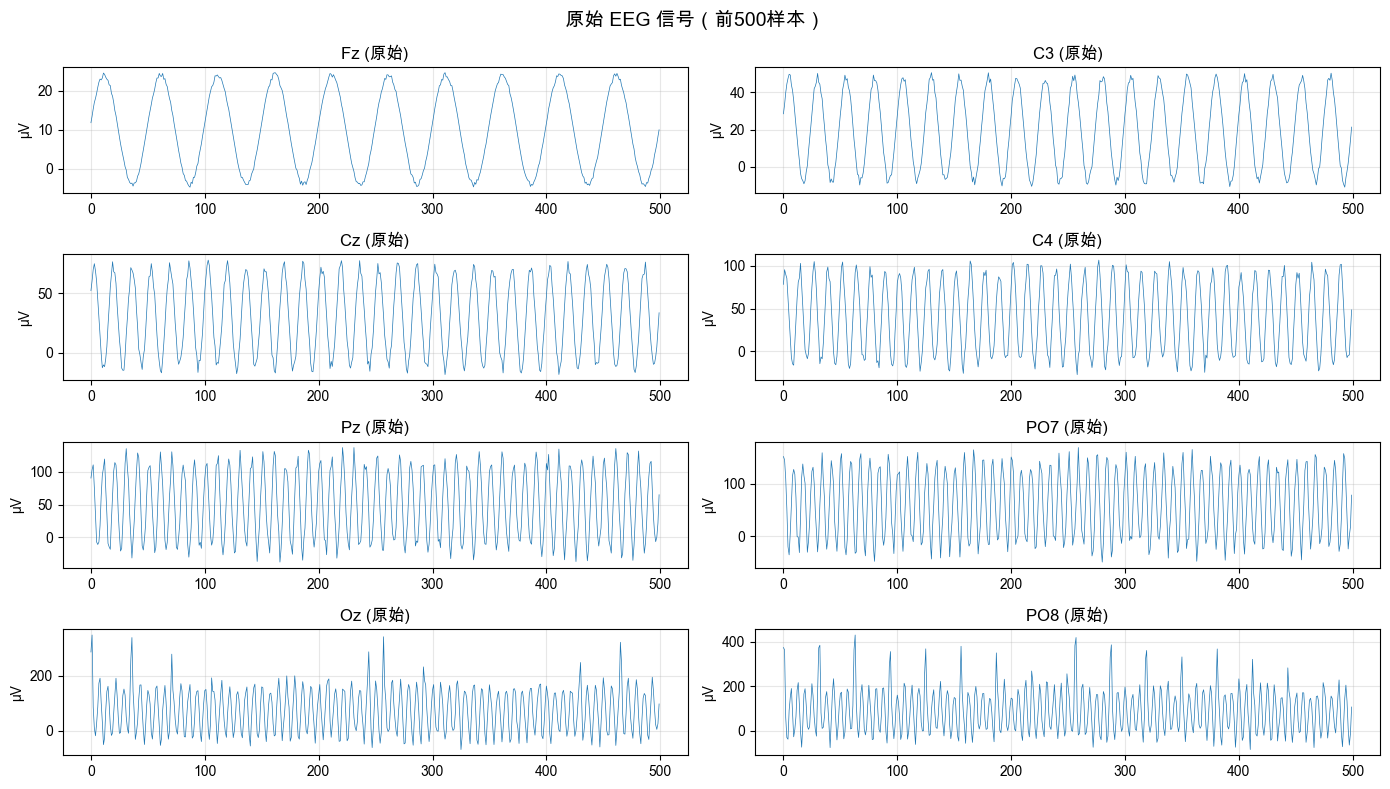

In [4]:
def collect_data(duration_sec=10):
    """采集 Synthetic Board 数据"""
    board = BoardShim(BoardIds.SYNTHETIC_BOARD, BrainFlowInputParams())
    board.prepare_session()
    board.start_stream()
    time.sleep(duration_sec)
    data = board.get_board_data()
    board.stop_stream()
    board.release_session()
    return data

data = collect_data(10)

descr = BoardShim.get_board_descr(BoardIds.SYNTHETIC_BOARD)
eeg_channels = descr['eeg_channels']
eeg_names = BoardShim.get_eeg_names(BoardIds.SYNTHETIC_BOARD)
sampling_rate = descr['sampling_rate']

print(f"板卡: {descr['name']}")
print(f"采样率: {sampling_rate} Hz")
print(f"数据形状: {data.shape}")
print(f"EEG 通道数: {len(eeg_channels)}")

# 绘制原始信号
fig, axes = plt.subplots(4, 2, figsize=(14, 8))
axes = axes.flatten()
for i in range(8):
    axes[i].plot(data[eeg_channels[i], :500], linewidth=0.5)
    axes[i].set_title(f'{eeg_names[i]} (原始)')
    axes[i].set_ylabel('μV')
    axes[i].grid(True, alpha=0.3)
plt.suptitle('原始 EEG 信号（前500样本）', fontsize=14)
plt.tight_layout()
plt.show()

## 4.2 去趋势（Detrending）

EEG 信号通常存在缓慢的基线漂移，去趋势是预处理的第一步。

| DetrendOperations | 说明 |函数|
|-------------------|------|------|
| CONSTANT | 减去均值（去除 DC 偏置） |b|
| LINEAR | 减去线性趋势（去除线性漂移） |ax+b|
| NONE | 不去趋势 |0|


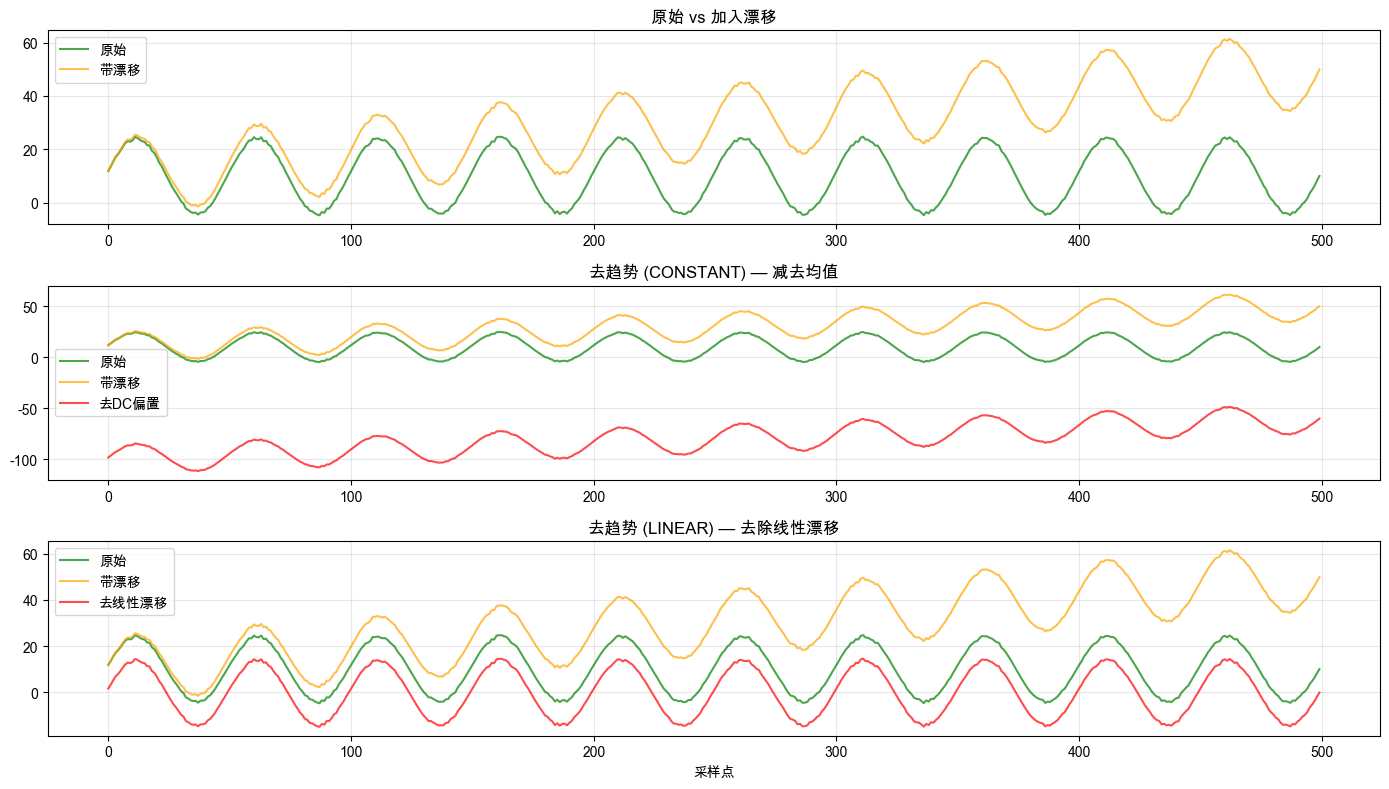

In [ ]:
# 演示去趋势效果 —— 在数据中加入漂移来展示
ch_idx = 0  # 使用第一个 EEG 通道
channel_data = data[eeg_channels[ch_idx], :].copy()

# 人为加入线性漂移以演示效果
drift = np.linspace(0, 200, len(channel_data)) # a*x+b
noisy_data = channel_data + drift

# 应用不同去趋势方法
detrend_constant = noisy_data.copy()
# 减去均值（去除 DC 偏置）
DataFilter.detrend(detrend_constant, DetrendOperations.CONSTANT.value)

detrend_linear = noisy_data.copy()
# 减去线性趋势（去除线性漂移）trend[i] ≈ 200 * i / (N - 1)
DataFilter.detrend(detrend_linear, DetrendOperations.LINEAR.value)

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

axes[0].plot(channel_data[:500], label='原始', color='green', alpha=0.7)
axes[0].plot(noisy_data[:500], label='带漂移', color='orange', alpha=0.7)
axes[0].legend()
axes[0].set_title('原始 vs 加入漂移')
axes[0].grid(True, alpha=0.3)

axes[1].plot(channel_data[:500], color='green', label='原始', alpha=0.7)
axes[1].plot(noisy_data[:500], color='orange', label='带漂移', alpha=0.7)
axes[1].plot(detrend_constant[:500], color='red', label='去DC偏置', alpha=0.7)
axes[1].legend()
axes[1].set_title('去趋势 (CONSTANT) — 减去均值')
axes[1].grid(True, alpha=0.3)

# LINEAR detrend 的目标不是还原原始信号
# LINEAR detrend 的目标是让数据不再有线性趋势，并且通常接近零均值
# 因此需要去掉 (线性漂移 + 一部分均值)
axes[2].plot(channel_data[:500], color='green', label='原始', alpha=0.7)
axes[2].plot(noisy_data[:500], color='orange', label='带漂移', alpha=0.7)
axes[2].plot(detrend_linear[:500], color='red', label='去线性漂移', alpha=0.7)
axes[2].legend()
axes[2].set_title('去趋势 (LINEAR) — 去除线性漂移')
axes[2].set_xlabel('采样点')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.3 数字滤波器

BrainFlow 的 `DataFilter` 提供了完整的 IIR 滤波器：

| 方法 | 功能 |
|------|------|
| `perform_lowpass` | 低通滤波 |
| `perform_highpass` | 高通滤波 |
| `perform_bandpass` | 带通滤波 |
| `perform_bandstop` | 带阻滤波（陷波） |

**关键参数说明**：
- `sampling_rate`: 采样率 (Hz)
- `order`: 滤波器阶数（越大越陡峭，但可能不稳定）
- `filter_type`: `FilterTypes.BUTTERWORTH`, `CHEBYSHEV`, `BESSEL`
- 带通/带阻：使用 `center_freq`（中心频率）和 `band_width`（带宽）描述

> 例如：bandpass 8-30Hz → center_freq = 19Hz, band_width = 22Hz

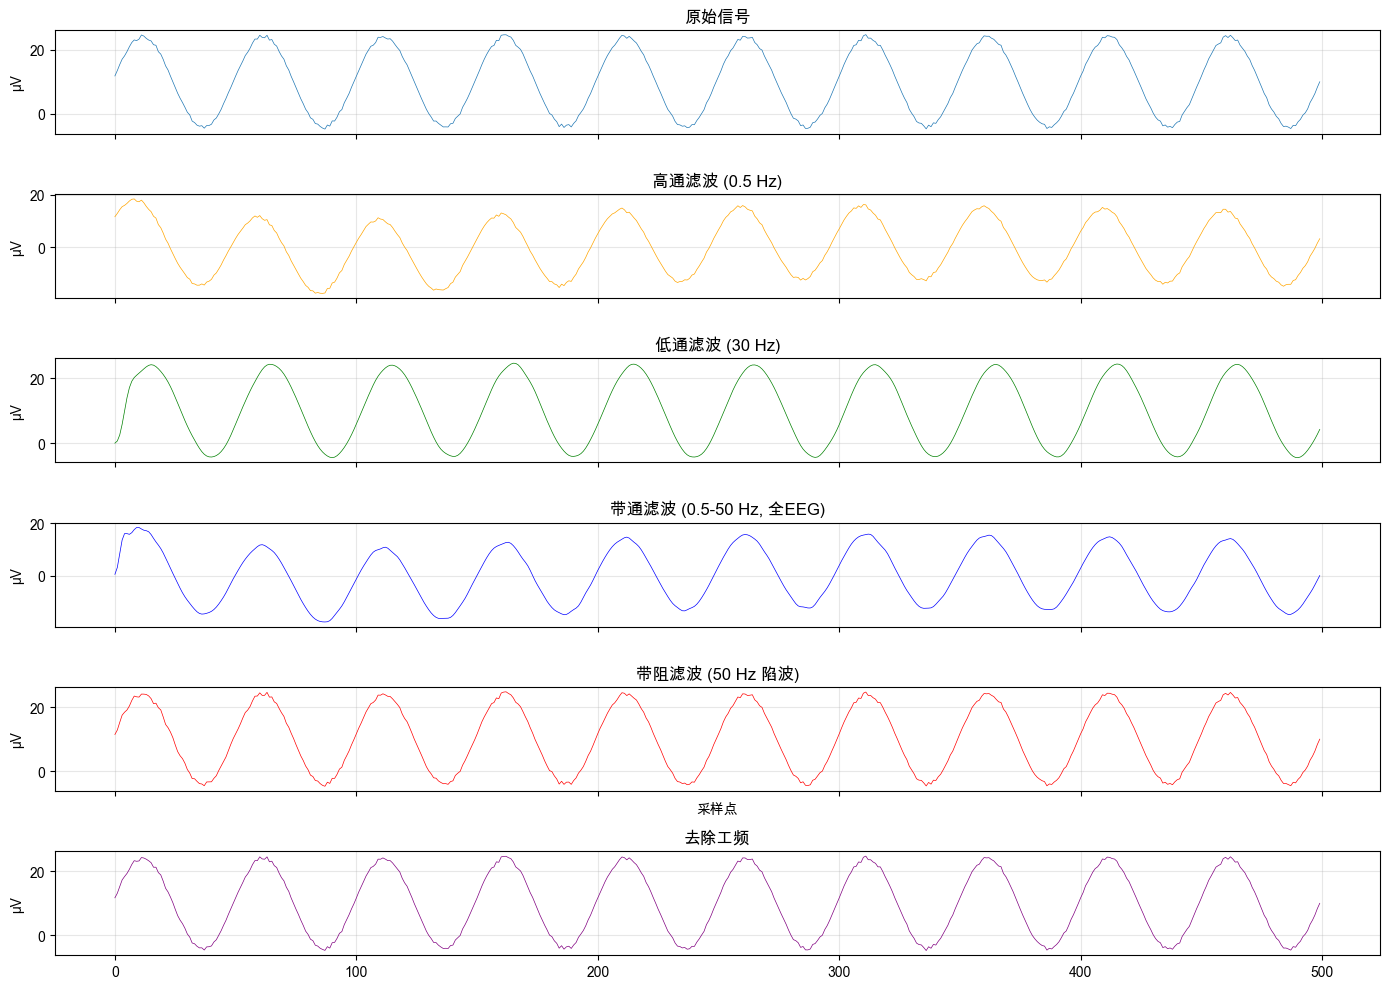

In [ ]:
# 在原始 signal 上对比不同滤波器的效果
ch_data = data[eeg_channels[0], :].copy()

# 1. 高通滤波 (0.5 Hz 截止，去除 DC 和超慢波)
highpass_data = ch_data.copy()
DataFilter.perform_highpass(
    data=highpass_data,     # 输入数据（会被原地修改）
    sampling_rate=sampling_rate,  # 采样率（Hz）
    cutoff=0.5,             # 截止频率（Hz）
    order=4,                # 滤波器阶数
    filter_type=FilterTypes.BUTTERWORTH.value,  # 滤波器类型：巴特沃斯
    ripple=0                # 纹波（巴特沃斯滤波器设为0）
)

# 2. 低通滤波 (30 Hz, alpha+beta 节律)
lowpass_data = ch_data.copy()
DataFilter.perform_lowpass(
    data=lowpass_data,     # 输入数据（会被原地修改）
    sampling_rate=sampling_rate,  # 采样率（Hz）
    cutoff=30.0,            # 截止频率（Hz）
    order=4,                # 滤波器阶数
    filter_type=FilterTypes.BUTTERWORTH.value,  # 滤波器类型：巴特沃斯
    ripple=0                # 纹波（巴特沃斯滤波器设为0）
)


# 3. 带通滤波 (0.5-50 Hz, 全 EEG 频段)
eeg_band_data = ch_data.copy()
DataFilter.perform_bandpass(
    data=eeg_band_data, 
    sampling_rate=sampling_rate,  # 采样率（Hz）
    start_freq=0.5,       # 低截止频率（Hz）
    stop_freq=50.0,        # 高截止频率（Hz）  
    order=4,                # 滤波器阶数
    filter_type=FilterTypes.BUTTERWORTH.value,  # 滤波器类型：巴特沃斯
    ripple=0                # 纹波（巴特沃斯滤波器设为0）
)

# 4. 带阻滤波 (50 Hz 陷波，去除工频)
DataFilter.perform_bandstop(
    data=notch_data,     # 输入数据（会被原地修改）
    sampling_rate=sampling_rate,  # 采样率（Hz）
    start_freq=49.5,       # 低截止频率（Hz）
    stop_freq=50.5,        # 高截止频率（Hz）  
    order=4,                # 滤波器阶数
    filter_type=FilterTypes.BUTTERWORTH.value,  # 滤波器类型：巴特沃斯
    ripple=0                # 纹波（巴特沃斯滤波器设为0）
)

# 5.去除工频
clean_data = ch_data.copy()
DataFilter.remove_environmental_noise(
    data=clean_data, 
    sampling_rate=sampling_rate, 
    noise_type=NoiseTypes.FIFTY
)

# 可视化对比
fig, axes = plt.subplots(6, 1, figsize=(14, 10), sharex=True)
plot_range = slice(0, 500)

axes[0].plot(ch_data[plot_range], linewidth=0.5)
axes[0].set_title('原始信号')

axes[1].plot(highpass_data[plot_range], linewidth=0.5, color='orange')
axes[1].set_title('高通滤波 (0.5 Hz)')

axes[2].plot(lowpass_data[plot_range], linewidth=0.5, color='green')
axes[2].set_title('低通滤波 (30 Hz)')

axes[3].plot(eeg_band_data[plot_range], linewidth=0.5, color='blue')
axes[3].set_title('带通滤波 (0.5-50 Hz, 全EEG)')

axes[4].plot(notch_data[plot_range], linewidth=0.5, color='red')
axes[4].set_title('带阻滤波 (50 Hz 陷波)')


axes[5].plot(clean_data[plot_range], linewidth=0.5, color='purple')
axes[5].set_title('去除工频')
axes[4].set_xlabel('采样点')



for ax in axes:
    ax.set_ylabel('μV')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.4 滚动平滑滤波器

滚动窗口滤波器用于平滑信号，减少高频噪声。

| AggOperations | 说明 |
|---------------|------|
| `MEAN` | 窗口内平均值 |
| `MEDIAN` | 窗口内中位数（抗异常值） |
| `MODE` | 窗口内众数 |

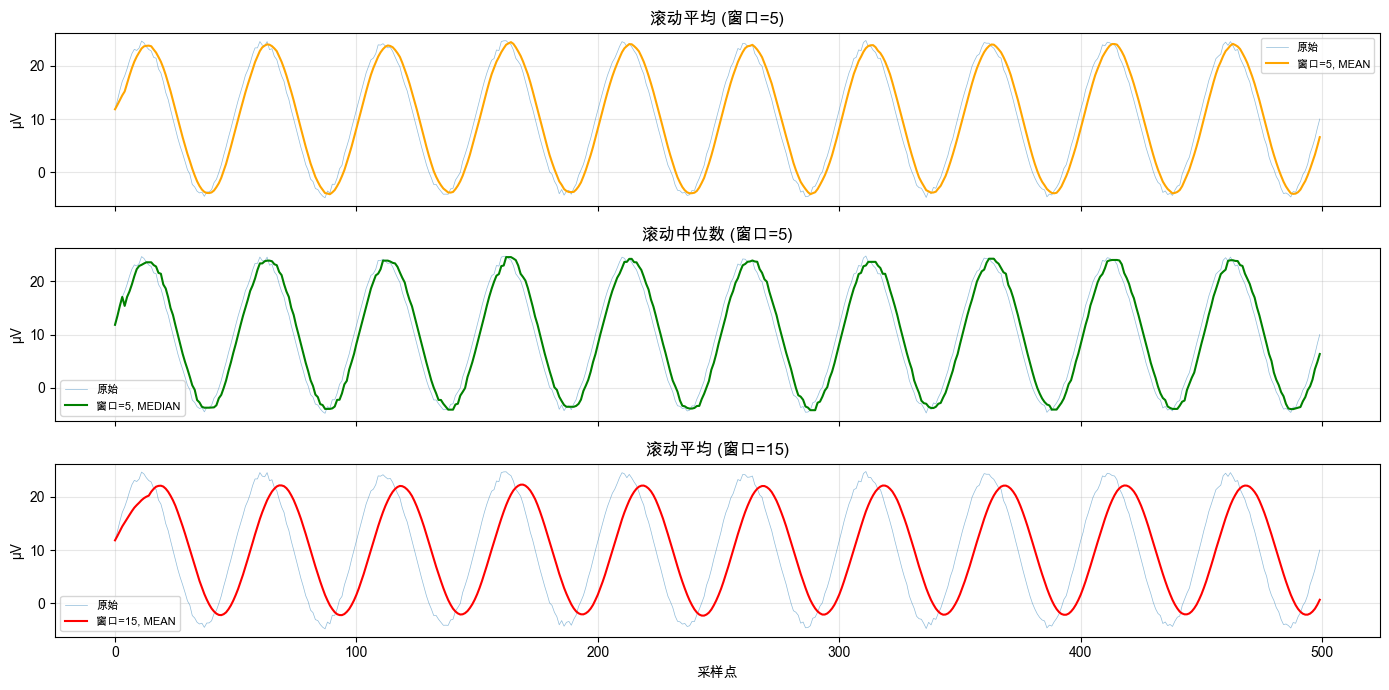

In [29]:
ch_data = data[eeg_channels[0], :500].copy()

# 滚动平均，边走边平均
# 当前点 + 过去点 做平均
# 平滑短时抖动、高频尖刺会被压低，但信号会产生一定滞后。
smoothed_mean = ch_data.copy()
DataFilter.perform_rolling_filter(
    data=smoothed_mean,      # 输入数据数组，将被原地修改
    period=5,                # 滚动窗口大小（采样点数）
    operation=AggOperations.MEAN.value  # 聚合操作类型：计算平均值
)

# 滚动中位数
smoothed_median = ch_data.copy()
DataFilter.perform_rolling_filter(
    data=smoothed_median,      # 输入数据数组，将被原地修改
    period=5,                # 滚动窗口大小（采样点数）
    operation=AggOperations.MEDIAN.value # 聚合操作类型：计算中位数
)

# 更大窗口的滚动平均值
smoothed_mean_wide = ch_data.copy()
DataFilter.perform_rolling_filter(
    data=smoothed_mean_wide,      # 输入数据数组，将被原地修改
    period=15,                # 滚动窗口大小（采样点数）
    operation=AggOperations.MEAN.value  # 聚合操作类型：计算平均值
)

fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

axes[0].plot(ch_data, linewidth=0.5, alpha=0.5, label='原始')
axes[0].plot(smoothed_mean, linewidth=1.5, label='窗口=5, MEAN', color='orange')
axes[0].legend(fontsize=8)
axes[0].set_title('滚动平均 (窗口=5)')

axes[1].plot(ch_data, linewidth=0.5, alpha=0.5, label='原始')
axes[1].plot(smoothed_median, linewidth=1.5, label='窗口=5, MEDIAN', color='green')
axes[1].legend(fontsize=8)
axes[1].set_title('滚动中位数 (窗口=5)')

axes[2].plot(ch_data, linewidth=0.5, alpha=0.5, label='原始')
axes[2].plot(smoothed_mean_wide, linewidth=1.5, label='窗口=15, MEAN', color='red')
axes[2].legend(fontsize=8)
axes[2].set_title('滚动平均 (窗口=15)')
axes[2].set_xlabel('采样点')

for ax in axes:
    ax.set_ylabel('μV')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.5 小波去噪

小波去噪是一种强大的信号增强技术，可以在保留信号特征的同时去除噪声。

`DataFilter.perform_wavelet_denoising(data, wavelet, decomposition_level)`

**常用小波函数**：`'db4'`, `'db6'`, `'bior3.9'`, `'sym7'`, `'coif3'`

| 小波 | 含义 | 特点 |
| :--- | :--- | :--- |
| DB4 | Daubechies 4 小波 | 比较常用，平衡性好，能保留较多瞬态变化 |
| DB6 | Daubechies 6 小波 | 更平滑，能表达更复杂的低频结构，但可能更容易平滑掉细节 |
| DB8 | Daubechies 8 小波 | 更长、更平滑，适合更平稳的信号 |

BrainFlow 官方示例中 perform_wavelet_denoising 的调用包含小波类型、分解层数、去噪方法、阈值类型、边界扩展方式、噪声估计层级等参数，说明它做的是完整的“小波阈值去噪”流程。

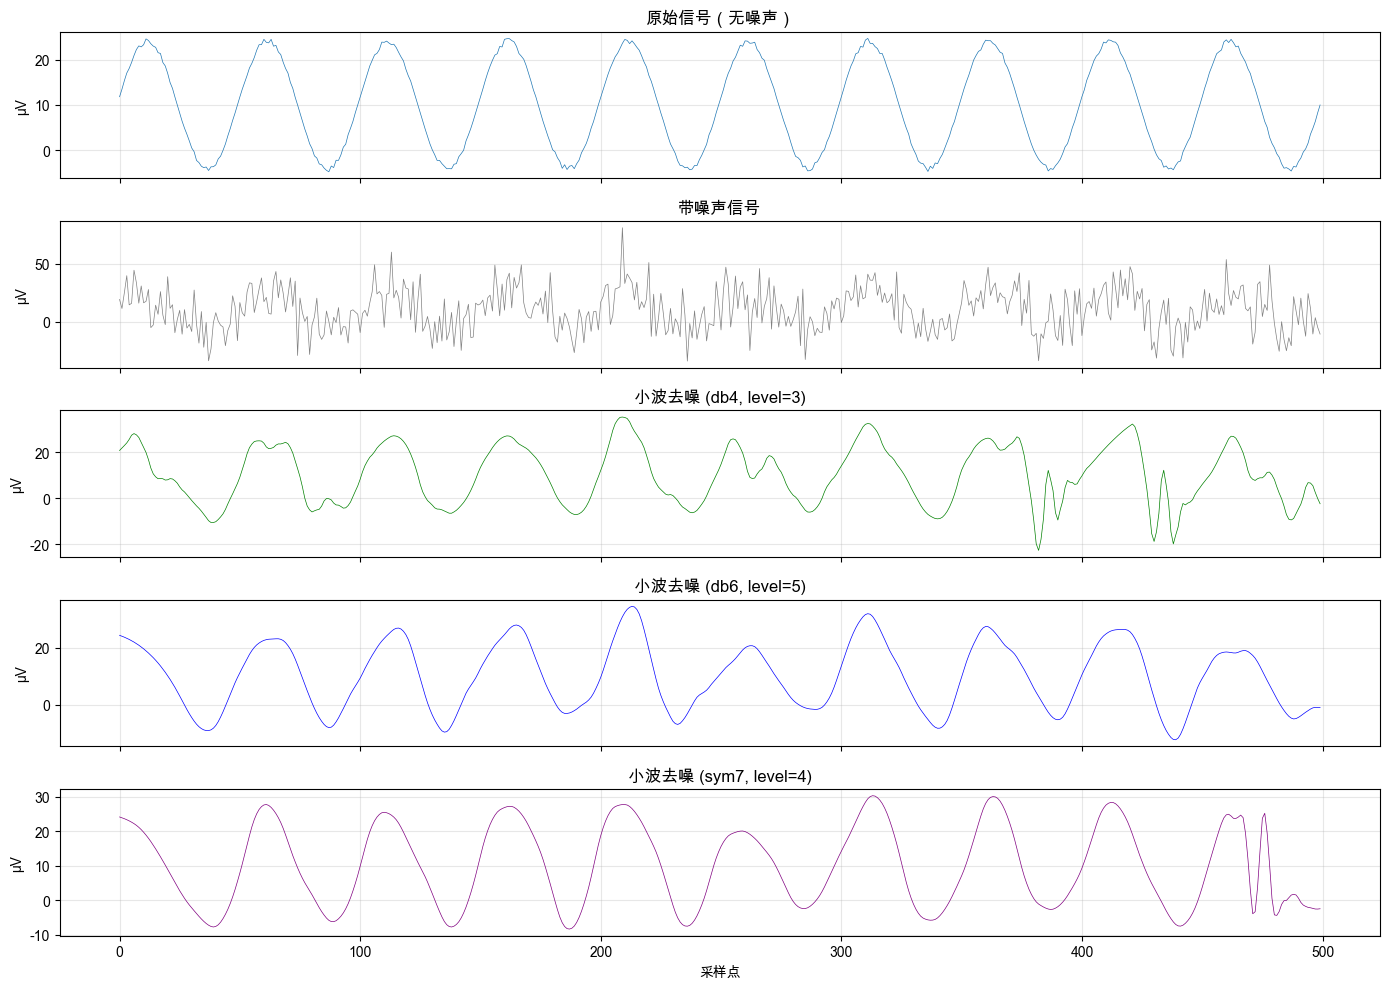

In [34]:
# 小波去噪对比
ch_data = data[eeg_channels[0], :500].copy()

# 添加一些人工噪声
np.random.seed(42)
noise = np.random.normal(0, 15, len(ch_data))
noisy_signal = ch_data + noise

# 不同小波去噪
denoised_db4 = noisy_signal.copy()
DataFilter.perform_wavelet_denoising(
    data=denoised_db4, 
    wavelet=WaveletTypes.DB4, 
    decomposition_level=3
)

denoised_db6 = noisy_signal.copy()
DataFilter.perform_wavelet_denoising(
    data=denoised_db6, 
    wavelet=WaveletTypes.DB6, 
    decomposition_level=5
)

denoised_sym7 = noisy_signal.copy()
DataFilter.perform_wavelet_denoising(
    data=denoised_sym7, 
    wavelet=WaveletTypes.SYM7, 
    decomposition_level=4
)

# 可视化
fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)

axes[0].plot(ch_data, linewidth=0.5)
axes[0].set_title('原始信号（无噪声）')

axes[1].plot(noisy_signal, linewidth=0.5, color='gray')
axes[1].set_title('带噪声信号')

axes[2].plot(denoised_db4, linewidth=0.5, color='green')
axes[2].set_title('小波去噪 (db4, level=3)')

axes[3].plot(denoised_db6, linewidth=0.5, color='blue')
axes[3].set_title('小波去噪 (db6, level=5)')

axes[4].plot(denoised_sym7, linewidth=0.5, color='purple')
axes[4].set_title('小波去噪 (sym7, level=4)')
axes[4].set_xlabel('采样点')

for ax in axes:
    ax.set_ylabel('μV')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


计算去噪效果 (RMSE)  
RMSE 是 Root Mean Squared Error，中文叫 均方根误差。  
它用来衡量两个信号之间的整体误差大小  
$ RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - x_i)^2} $

In [ ]:


print("去噪效果评估 (RMSE 越低越好):")
print(f"  噪声信号:     {np.sqrt(np.mean((noisy_signal - ch_data) ** 2)):.2f}")
print(f"  db4 去噪后:   {np.sqrt(np.mean((denoised_db4 - ch_data) ** 2)):.2f}")
print(f"  db6 去噪后:   {np.sqrt(np.mean((denoised_db6 - ch_data) ** 2)):.2f}")
print(f"  sym7 去噪后:  {np.sqrt(np.mean((denoised_sym7 - ch_data) ** 2)):.2f}")

去噪效果评估 (RMSE 越低越好):
  噪声信号:     14.70
  db4 去噪后:   5.79
  db6 去噪后:   4.13
  sym7 去噪后:  4.29


## 4.6 环境噪声去除

BrainFlow 提供了便捷的工频噪声去除方法：

| NoiseTypes | 说明 |
|------------|------|
| `FIFTY` | 50 Hz 工频（中国、欧洲） |
| `SIXTY` | 60 Hz 工频（美国） |
| `FIFTY_AND_SIXTY` | 同时去除 50 和 60 Hz |

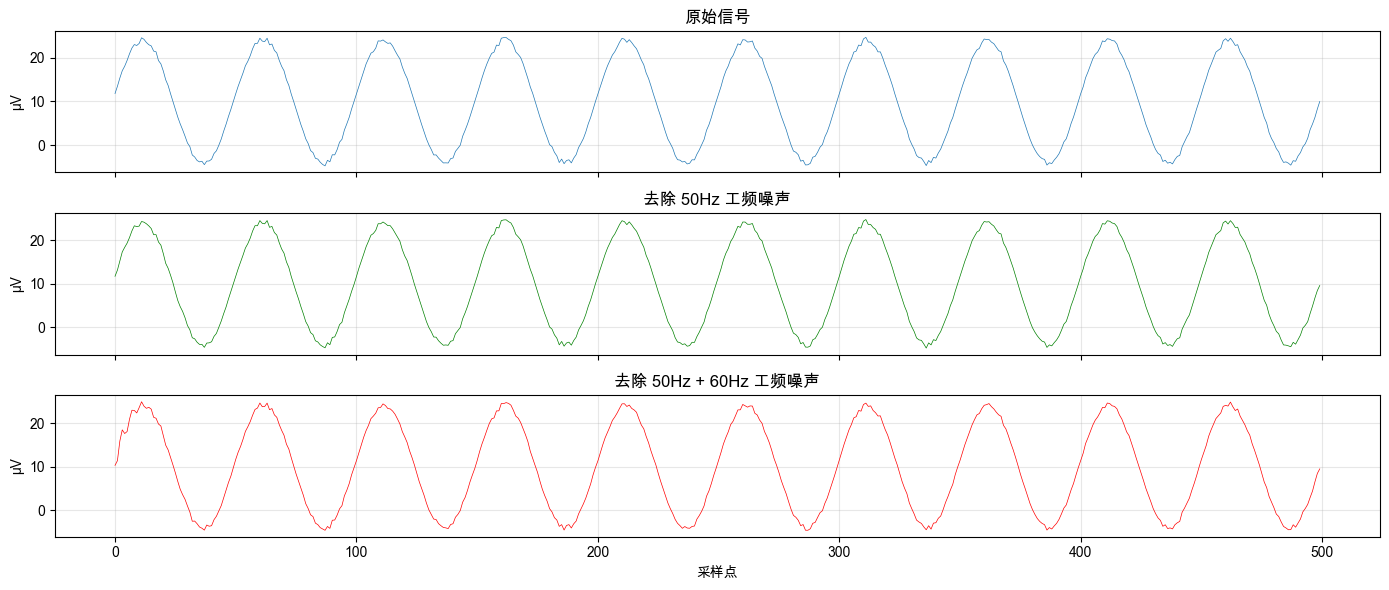

In [36]:
# 去除环境工频噪声
ch_data = data[eeg_channels[0], :500].copy()

cleaned_fifty = ch_data.copy()
DataFilter.remove_environmental_noise(cleaned_fifty, sampling_rate,
                                        NoiseTypes.FIFTY.value)

cleaned_both = ch_data.copy()
DataFilter.remove_environmental_noise(cleaned_both, sampling_rate,
                                        NoiseTypes.FIFTY_AND_SIXTY.value)

fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)

axes[0].plot(ch_data, linewidth=0.5)
axes[0].set_title('原始信号')

axes[1].plot(cleaned_fifty, linewidth=0.5, color='green')
axes[1].set_title('去除 50Hz 工频噪声')

axes[2].plot(cleaned_both, linewidth=0.5, color='red')
axes[2].set_title('去除 50Hz + 60Hz 工频噪声')
axes[2].set_xlabel('采样点')

for ax in axes:
    ax.set_ylabel('μV')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4.7 标准信号处理流水线

将所学步骤组合成一条标准的 EEG 预处理流水线：

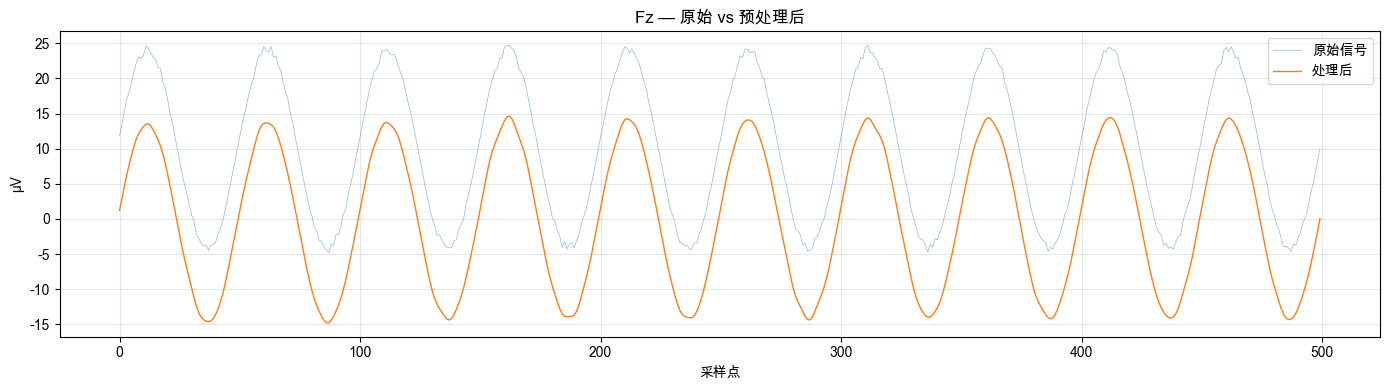

✅ 标准预处理流水线就绪
   1. 去线性趋势
   2. 带通滤波 (0.5-45 Hz)
   3. 50Hz 陷波


In [ ]:
def preprocess_eeg(data, channel_idx, sampling_rate, 
                   lowcut=0.5, highcut=45.0, notch_freq=50.0):
    """
    标准 EEG 预处理流水线:
    1. 去线性趋势
    2. 带通滤波 (保留有效 EEG 频段)
    3. 陷波滤波 (去除工频干扰)
    """
    # 复制数据，避免修改原始数据
    signal = data[channel_idx].copy().astype(np.float64)
    
    # Step 1: 去线性趋势
    DataFilter.detrend(signal, DetrendOperations.LINEAR.value)
    
    # Step 2: 带通滤波
    DataFilter.perform_bandpass(
        signal, 
        sampling_rate,
        start_freq=lowcut, 
        stop_freq=highcut, 
        order=4,
        filter_type=FilterTypes.BUTTERWORTH_ZERO_PHASE.value, # 无相位延迟
        ripple=0
    )
    
    # Step 3: 陷波滤波
    DataFilter.perform_bandstop(
        signal, 
        sampling_rate,
        start_freq=notch_freq-0.5, 
        stop_freq=notch_freq+0.5, 
        order=4,
        filter_type=FilterTypes.BUTTERWORTH_ZERO_PHASE.value, # 无相位延迟
        ripple=0
    )
    
    return signal

# 测试流水线
ch_idx = eeg_channels[0]
raw_signal = data[ch_idx, :].copy()
processed_signal = preprocess_eeg(data, ch_idx, sampling_rate)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(raw_signal[:500], alpha=0.5, linewidth=0.5, label='原始信号')
ax.plot(processed_signal[:500], linewidth=1, label='处理后')
ax.set_title(f'{eeg_names[0]} — 原始 vs 预处理后')
ax.set_xlabel('采样点')
ax.set_ylabel('μV')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ 标准预处理流水线就绪")
print(f"   1. 去线性趋势")
print(f"   2. 带通滤波 (0.5-45 Hz)")
print(f"   3. 50Hz 陷波")

## 4.8 对所有通道批量处理

在实际应用中，需要对所有 EEG 通道执行相同的预处理。

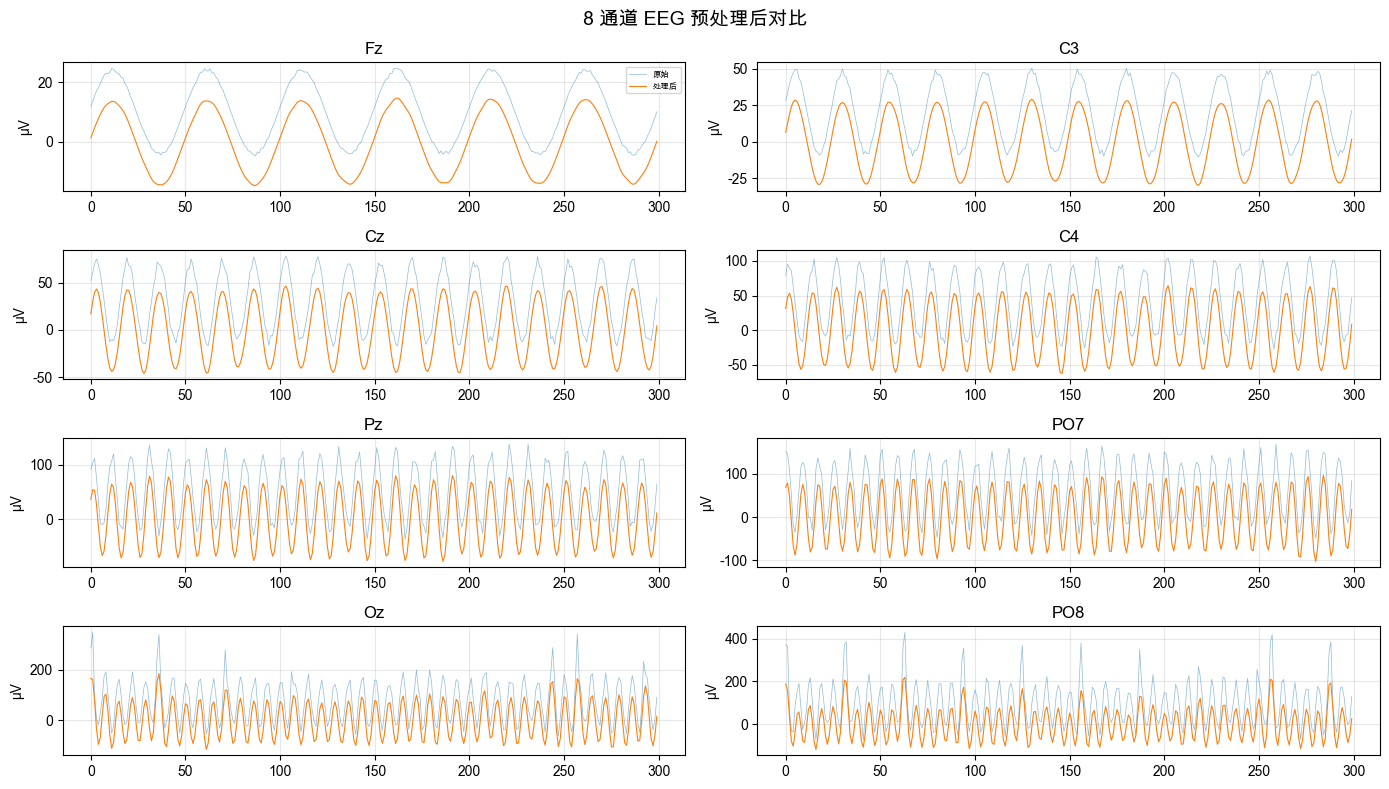

✅ 全通道预处理完成


In [43]:
# 对所有 EEG 通道执行预处理
eeg_data = data[eeg_channels, :].copy().astype(np.float64)
processed_eeg = np.zeros_like(eeg_data)

for i in range(len(eeg_channels)):
    processed_eeg[i] = preprocess_eeg(data, eeg_channels[i], sampling_rate)

# 对比处理前后
fig, axes = plt.subplots(4, 2, figsize=(14, 8))
axes = axes.flatten()

for i in range(8):
    axes[i].plot(eeg_data[i, :300], linewidth=0.5, alpha=0.5, label='原始')
    axes[i].plot(processed_eeg[i, :300], linewidth=0.8, label='处理后')
    axes[i].set_title(eeg_names[i])
    axes[i].set_ylabel('μV')
    axes[i].grid(True, alpha=0.3)
    if i == 0:
        axes[i].legend(fontsize=6)

plt.suptitle('8 通道 EEG 预处理后对比', fontsize=14)
plt.tight_layout()
plt.show()
print("✅ 全通道预处理完成")



→ [Unit 5: 频域分析与特征提取](unit5_frequency_analysis.ipynb) — 频带功率、PSD、特征向量